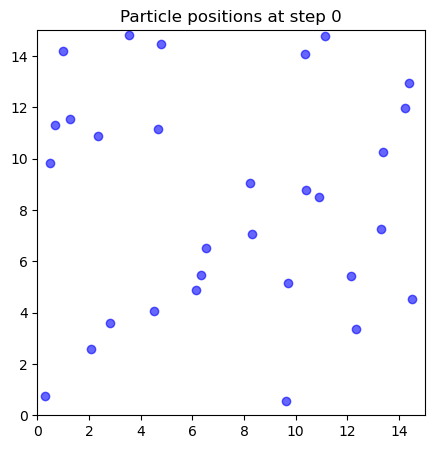

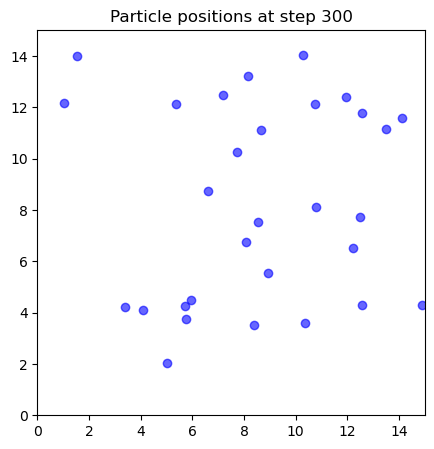

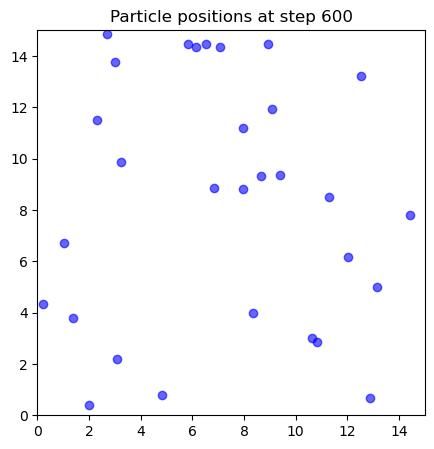

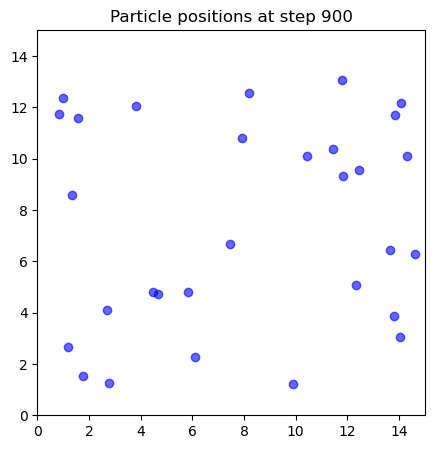

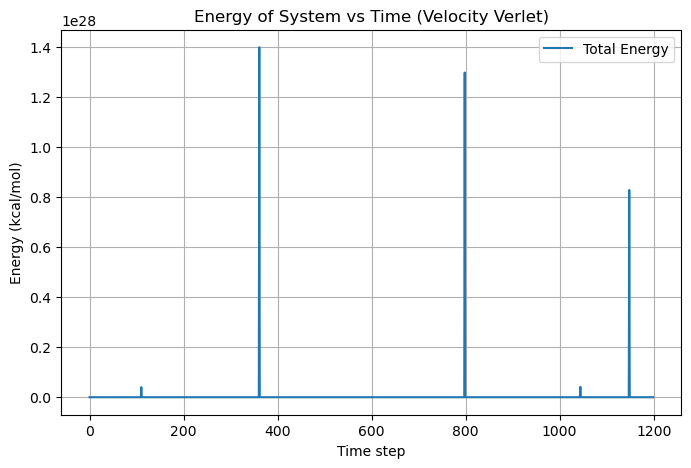

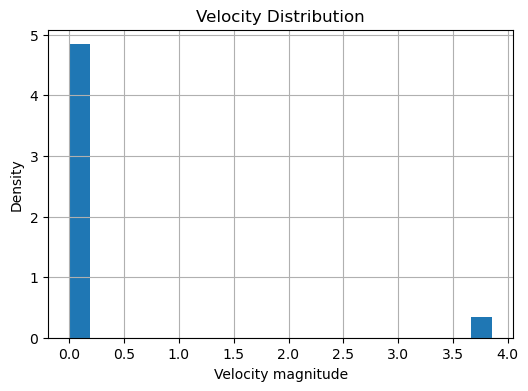

In [9]:
import numpy as np
import matplotlib.pyplot as plt

N = 30
L = 15.0
steps = 1200
dt = 0.005
m = 1.2
sigma = 3.8
epsilon = 0.4
T_target = 300.0
kB = 0.001987

coords = np.random.uniform(0, L, (N, 2))
velocities = np.random.normal(0, 1, (N, 2))

def pbc(x):
    return x % L

def forces(coords):
    F = np.zeros_like(coords)
    E = 0.0
    for i in range(N):
        for j in range(i+1, N):
            dx = coords[i,0] - coords[j,0]
            dy = coords[i,1] - coords[j,1]
            dx -= L * np.round(dx / L)
            dy -= L * np.round(dy / L)
            r = np.sqrt(dx*dx + dy*dy)
            if r > 0:
                sr6 = (sigma/r)**6
                sr12 = sr6*sr6
                E += 4*epsilon*(sr12 - sr6)
                f = 24*epsilon*(2*sr12 - sr6)/r**2
                F[i,0] += f*dx
                F[i,1] += f*dy
                F[j,0] -= f*dx
                F[j,1] -= f*dy
    return F, E

energies = []
F, E_pot = forces(coords)

for step in range(steps):
    coords = pbc(coords + velocities*dt + 0.5*F/m*dt**2)
    F_new, E_pot = forces(coords)
    velocities = velocities + 0.5*(F + F_new)/m*dt
    F = F_new

    E_kin = 0.5*m*np.sum(velocities**2)
    T_current = E_kin / (N * kB)
    scale = np.sqrt(T_target / T_current)
    velocities *= scale
    E_kin *= scale**2
    E_tot = E_pot + E_kin
    energies.append(E_tot)

    if step % 300 == 0:
        plt.figure(figsize=(5,5))
        plt.scatter(coords[:,0], coords[:,1], c='blue', alpha=0.6)
        plt.xlim(0, L)
        plt.ylim(0, L)
        plt.title(f"Particle positions at step {step}")
        plt.show()

plt.figure(figsize=(8,5))
plt.plot(energies, label="Total Energy")
plt.xlabel("Time step")
plt.ylabel("Energy (kcal/mol)")
plt.title("Energy of System vs Time (Velocity Verlet)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(np.sqrt(np.sum(velocities**2, axis=1)), bins=20, density=True)
plt.xlabel("Velocity magnitude")
plt.ylabel("Density")
plt.title("Velocity Distribution")
plt.grid(True)
plt.show()